# 02 — PyCAP Baseline Run Check

**Purpose:** Confirm that the copied Little Plover River PyCAP analytical model can be inspected and rerun from this clean repository.

This notebook checks that the PyCAP model can be:

1. Found in the raw copied PyCAP folder.
2. Copied into a safe `results/` run folder.
3. Loaded from the baseline YAML file.
4. Rerun using `pycap.analysis_project.Project`.
5. Checked for expected output tables.
6. Compared against the original copied baseline outputs.
7. Used to calculate a basic depletion-potential table.

## Important idea

We will **not** run PyCAP directly inside:

```text
data/raw/lpr_pycap/pycap_base/
```

That folder is treated as the clean copied baseline from `LPR_redux`.

Instead, this notebook creates a run workspace in:

```text
results/pycap_runs/baseline_pycap/
```

and runs PyCAP there.


## 1. Imports and project-root setup

In [25]:
from pathlib import Path
import os
import sys
import shutil
import json
import time
from datetime import datetime

import numpy as np
import pandas as pd
import yaml

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define source and run paths

In [26]:
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"

# Clean copied PyCAP source folders
LPR_PYCAP_RAW_DIR = DATA_DIR / "raw" / "lpr_pycap"
LPR_PYCAP_BASE_SOURCE_DIR = LPR_PYCAP_RAW_DIR / "pycap_base"
LPR_PYCAP_INPUTS_DIR = LPR_PYCAP_RAW_DIR / "inputs"

# Safe run workspace for this notebook
BASELINE_PYCAP_RUN_DIR = PYCAP_RESULTS_DIR / "baseline_pycap"
BASELINE_PYCAP_OUTPUT_DIR = BASELINE_PYCAP_RUN_DIR / "output"

PYCAP_RUN_NAME = "LPR_Redux"
PYCAP_YAML_NAME = f"{PYCAP_RUN_NAME}.yml"

print(f"PyCAP source folder: {LPR_PYCAP_BASE_SOURCE_DIR}")
print(f"PyCAP inputs folder: {LPR_PYCAP_INPUTS_DIR}")
print(f"PyCAP run folder:    {BASELINE_PYCAP_RUN_DIR}")


PyCAP source folder: /workspaces/Modeling-Uncertainties/data/raw/lpr_pycap/pycap_base
PyCAP inputs folder: /workspaces/Modeling-Uncertainties/data/raw/lpr_pycap/inputs
PyCAP run folder:    /workspaces/Modeling-Uncertainties/results/pycap_runs/baseline_pycap


## 3. Check the source PyCAP files

These are the copied baseline files from the original LPR project.


In [27]:
required_pycap_source_files = [
    LPR_PYCAP_BASE_SOURCE_DIR / PYCAP_YAML_NAME,
    LPR_PYCAP_BASE_SOURCE_DIR / "depletion_potential.json",
    LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.report.txt",
    LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.table_report.csv",
    LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
    LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
]

source_file_check = pd.DataFrame(
    [
        {
            "file": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_MB": round(path.stat().st_size / 1_000_000, 3) if path.exists() else None,
        }
        for path in required_pycap_source_files
    ]
)

source_file_check


,file,relative_path,exists,size_MB
0,LPR_Redux.yml,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml,True,0.108
1,depletion_potential.json,data/raw/lpr_pycap/pycap_base/depletion_potent...,True,0.093
2,LPR_Redux.report.txt,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,0.149
3,LPR_Redux.table_report.csv,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,0.141
4,LPR_Redux.table_report.all_ts.csv,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,13.149
5,LPR_Redux.table_report.base_stream_depletion.csv,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,0.009


In [28]:
missing_files = source_file_check.loc[~source_file_check["exists"], "relative_path"].tolist()

if missing_files:
    raise FileNotFoundError(f"Missing required PyCAP source files: {missing_files}")

print("All required copied PyCAP source files were found.")


All required copied PyCAP source files were found.


## 4. Check PyCAP imports

For this installed package, the import name should be `pycap`, and the main project class should be available from:

```python
from pycap.analysis_project import Project
```


In [29]:
try:
    import pycap
    from pycap.analysis_project import Project

    print("PyCAP imported successfully.")
    print(f"pycap module: {pycap}")
    print(f"Project class: {Project}")

except Exception as err:
    print("PyCAP import failed.")
    print(type(err).__name__)
    print(err)
    raise


PyCAP imported successfully.
pycap module: <module 'pycap' from '/opt/conda/envs/gw_uncertainty/lib/python3.11/site-packages/pycap/__init__.py'>
Project class: <class 'pycap.analysis_project.Project'>


## 5. Read and inspect the baseline YAML file

This helps us understand what is inside the PyCAP analytical model before running it.


In [30]:
source_yaml_path = LPR_PYCAP_BASE_SOURCE_DIR / PYCAP_YAML_NAME

with open(source_yaml_path, "r") as f:
    pycap_config = yaml.safe_load(f)

print(f"Loaded YAML: {source_yaml_path.relative_to(PROJECT_ROOT)}")
print(f"Top-level type: {type(pycap_config)}")
print(f"Number of top-level keys: {len(pycap_config)}")

print("\nFirst 25 top-level keys:")
for key in list(pycap_config.keys())[:25]:
    print(f"  - {key}")


Loaded YAML: data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
Top-level type: <class 'dict'>
Number of top-level keys: 656

First 25 top-level keys:
  - project_properties
  - well_418
  - well_466
  - well_467
  - well_490
  - well_509
  - well_602
  - well_603
  - well_798
  - well_807
  - well_850
  - well_862
  - well_1013
  - well_1302
  - well_1323
  - well_1486
  - well_1584
  - well_1589
  - well_1643
  - well_1683
  - well_1860
  - well_2544
  - well_2750
  - well_2886
  - well_3473


## 6. Inventory the well entries in the YAML

This cell extracts a simple well table from the YAML file.

The original LPR PyCAP notebooks use the YAML well entries to pull well names, pumping rates, and coordinates.


In [31]:
GPM_TO_CFS = 1 / 7.48052 / 60

well_keys = [key for key in pycap_config.keys() if "well" in str(key).lower()]

well_rows = []

for well_key in well_keys:
    entry = pycap_config[well_key]
    loc = entry.get("loc", {}) if isinstance(entry, dict) else {}

    q_gpm = entry.get("Q", np.nan) if isinstance(entry, dict) else np.nan
    q_cfs = q_gpm * GPM_TO_CFS if pd.notna(q_gpm) else np.nan

    well_rows.append(
        {
            "well_id": well_key,
            "name": entry.get("name", well_key) if isinstance(entry, dict) else well_key,
            "Q_gpm": q_gpm,
            "Q_cfs": q_cfs,
            "x": loc.get("x", np.nan),
            "y": loc.get("y", np.nan),
        }
    )

wells_df = pd.DataFrame(well_rows)

print(f"Number of well entries found: {len(wells_df)}")
wells_df.head()


Number of well entries found: 327


,well_id,name,Q_gpm,Q_cfs,x,y
0,well_418,418,109.5,0.243967,89.483927,44.443073
1,well_466,466,315.9,0.703828,89.493950,44.461175
2,well_467,467,296.9,0.661496,89.493973,44.458573
3,well_490,490,27.7,0.061716,89.312108,44.466657
4,well_509,509,0.1,0.000223,89.471377,44.520602


In [32]:
wells_df.describe(include="all")


,well_id,name,Q_gpm,Q_cfs,x,y
count,327,327,327.000000,327.000000,327.000000,327.000000
unique,327,327,NaN,NaN,NaN,NaN
top,well_418,418,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN
mean,NaN,NaN,159.857187,0.356163,89.450443,44.472320
std,NaN,NaN,147.298725,0.328183,0.063534,0.051243
min,NaN,NaN,0.100000,0.000223,89.287740,44.382800
25%,NaN,NaN,42.950000,0.095693,89.422466,44.431238
50%,NaN,NaN,132.900000,0.296102,89.456558,44.463364
75%,NaN,NaN,244.150000,0.543968,89.495926,44.504048


## 7. Inspect project-level PyCAP properties

This cell looks for commonly important global inputs like transmissivity `T` and storage `S`.

These are important for later uncertainty experiments.


In [33]:
project_properties = pycap_config.get("project_properties", {})

if not isinstance(project_properties, dict):
    print("No dictionary-like project_properties section was found.")
else:
    project_properties_table = pd.DataFrame(
        [
            {"property": key, "value": value, "type": type(value).__name__}
            for key, value in project_properties.items()
        ]
    )
    display(project_properties_table)


,property,value,type
0,name,LPR_Redux,str
1,T,1700.0,float
2,Max_T,60000.0,float
3,Min_T,600.0,float
4,S,0.12,float
5,Max_S,0.2,float
6,Min_S,0.05,float
7,Max_FracInt,1.0,float
8,Min_FracInt,0.0,float
9,default_dd_days,90.0,float


## 8. Prepare a clean PyCAP run folder

This copies only the YAML file into the run folder first.

We intentionally do **not** copy the old `output/` folder, so any output files we see afterward were produced by this notebook run.


In [34]:
OVERWRITE_RUN_FOLDER = True

if BASELINE_PYCAP_RUN_DIR.exists():
    if OVERWRITE_RUN_FOLDER:
        print(f"Removing existing run folder: {BASELINE_PYCAP_RUN_DIR.relative_to(PROJECT_ROOT)}")
        shutil.rmtree(BASELINE_PYCAP_RUN_DIR)
    else:
        raise FileExistsError(
            f"The run folder already exists: {BASELINE_PYCAP_RUN_DIR}. "
            "Set OVERWRITE_RUN_FOLDER = True if you want to replace it."
        )

BASELINE_PYCAP_RUN_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_PYCAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

run_yaml_path = BASELINE_PYCAP_RUN_DIR / PYCAP_YAML_NAME
shutil.copy2(source_yaml_path, run_yaml_path)

print(f"Copied YAML to: {run_yaml_path.relative_to(PROJECT_ROOT)}")
print(f"Output folder:   {BASELINE_PYCAP_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


Removing existing run folder: results/pycap_runs/baseline_pycap
Copied YAML to: results/pycap_runs/baseline_pycap/LPR_Redux.yml
Output folder:   results/pycap_runs/baseline_pycap/output


## 9. Run the baseline PyCAP model

The legacy `run_pycap.py` script does essentially this:

```python
ap = Project(datapath / yml_file)
ap.report_responses()
ap.write_responses_csv()
```

We use that same direct PyCAP workflow here, but inside this clean run folder.


In [35]:
start_time = datetime.now()

# PyCAP writes outputs relative to the YAML/run folder.
# Changing into the run folder makes this behavior explicit and easy to understand.
old_cwd = Path.cwd()
os.chdir(BASELINE_PYCAP_RUN_DIR)

try:
    ap = Project(run_yaml_path)
    print("Project object created.")

    print("Running ap.report_responses() ...")
    report_result = ap.report_responses()

    print("Running ap.write_responses_csv() ...")
    csv_result = ap.write_responses_csv()

finally:
    os.chdir(old_cwd)

end_time = datetime.now()
elapsed = end_time - start_time

print(f"PyCAP baseline run completed.")
print(f"Elapsed time: {elapsed}")


Writing report to /workspaces/Modeling-Uncertainties/results/pycap_runs/baseline_pycap/LPR_Redux.yml.import_report



Successfully parsed /workspaces/Modeling-Uncertainties/results/pycap_runs/baseline_pycap/LPR_Redux.yml (high five!)
*************************
Summary follows:

WELLS:
326 existing wells:
	466
	467
	490
	509
	602
	603
	798
	807
	850
	862
	1013
	1302
	1323
	1486
	1584
	1589
	1643
	1683
	1860
	2544
	2750
	2886
	3473
	3949
	4171
	23610
	23611
	23618
	23620
	23627
	23629
	23630
	23631
	23635
	23637
	23638
	23639
	23645
	23646
	23648
	23653
	23695
	23697
	23698
	23699
	23700
	23709
	23710
	23715
	23716
	23720
	23721
	23722
	23723
	23726
	23727
	23728
	23729
	23751
	23752
	23753
	23754
	23755
	23756
	23757
	23758
	23770
	23776
	23778
	23781
	23790
	23791
	23794
	23795
	23798
	23800
	23807
	23816
	23818
	23820
	23823
	23836
	23837
	23846
	23847
	23848
	23851
	23864
	23865
	23866
	23867
	23868
	23869
	23870
	23876
	23881
	23883
	23886
	23888
	23889
	23890
	23895
	23898
	23908
	2

## 10. List generated PyCAP output files

In [36]:
generated_files = sorted([p for p in BASELINE_PYCAP_RUN_DIR.rglob("*") if p.is_file()])

generated_file_table = pd.DataFrame(
    [
        {
            "file": p.name,
            "relative_path": str(p.relative_to(PROJECT_ROOT)),
            "size_MB": round(p.stat().st_size / 1_000_000, 3),
            "modified_time": datetime.fromtimestamp(p.stat().st_mtime).isoformat(timespec="seconds"),
        }
        for p in generated_files
    ]
)

generated_file_table


,file,relative_path,size_MB,modified_time
0,LPR_Redux.yml,results/pycap_runs/baseline_pycap/LPR_Redux.yml,0.108,2026-04-19T03:36:55
1,LPR_Redux.yml.import_report,results/pycap_runs/baseline_pycap/LPR_Redux.ym...,0.006,2026-04-19T05:10:56
2,LPR_Redux.report.txt,results/pycap_runs/baseline_pycap/output/LPR_R...,0.149,2026-04-19T05:10:58
3,LPR_Redux.table_report.all_ts.csv,results/pycap_runs/baseline_pycap/output/LPR_R...,13.149,2026-04-19T05:10:59
4,LPR_Redux.table_report.base_stream_depletion.csv,results/pycap_runs/baseline_pycap/output/LPR_R...,0.009,2026-04-19T05:10:58
5,LPR_Redux.table_report.csv,results/pycap_runs/baseline_pycap/output/LPR_R...,0.141,2026-04-19T05:10:58


## 11. Check for expected PyCAP output tables

In [37]:
expected_output_files = {
    "report_txt": BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.report.txt",
    "table_report": BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.csv",
    "all_ts": BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
    "base_stream_depletion": BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
}

expected_output_check = pd.DataFrame(
    [
        {
            "output": label,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_MB": round(path.stat().st_size / 1_000_000, 3) if path.exists() else None,
        }
        for label, path in expected_output_files.items()
    ]
)

expected_output_check


,output,relative_path,exists,size_MB
0,report_txt,results/pycap_runs/baseline_pycap/output/LPR_R...,True,0.149
1,table_report,results/pycap_runs/baseline_pycap/output/LPR_R...,True,0.141
2,all_ts,results/pycap_runs/baseline_pycap/output/LPR_R...,True,13.149
3,base_stream_depletion,results/pycap_runs/baseline_pycap/output/LPR_R...,True,0.009


In [38]:
missing_outputs = expected_output_check.loc[~expected_output_check["exists"], "relative_path"].tolist()

if missing_outputs:
    raise FileNotFoundError(
        "The PyCAP run finished, but some expected output files are missing: "
        f"{missing_outputs}"
    )

print("All expected PyCAP output files were created.")


All expected PyCAP output files were created.


## 12. Read the generated PyCAP output tables

In [39]:
run_tables = {}

for label, path in expected_output_files.items():
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        run_tables[label] = df
        print(f"{label}: shape = {df.shape}")
        print(f"columns = {list(df.columns)[:10]}")
        print("-" * 80)

run_tables["table_report"].head()


table_report: shape = (330, 329)
columns = ['Unnamed: 0', 'LakeEmily:dd (ft)', 'LPR:466:depl (cfs)', 'LPR:467:depl (cfs)', 'LPR:490:depl (cfs)', 'LPR:509:depl (cfs)', 'LPR:602:depl (cfs)', 'LPR:603:depl (cfs)', 'LPR:798:depl (cfs)', 'LPR:807:depl (cfs)']
--------------------------------------------------------------------------------
all_ts: shape = (1825, 328)
columns = ['Unnamed: 0', 'LPR:466', 'LPR:467', 'LPR:490', 'LPR:509', 'LPR:602', 'LPR:603', 'LPR:798', 'LPR:807', 'LPR:850']
--------------------------------------------------------------------------------
base_stream_depletion: shape = (330, 2)
columns = ['Unnamed: 0', 'LPR']
--------------------------------------------------------------------------------


,Unnamed: 0,LakeEmily:dd (ft),LPR:466:depl (cfs),LPR:467:depl (cfs),LPR:490:depl (cfs),LPR:509:depl (cfs),LPR:602:depl (cfs),LPR:603:depl (cfs),LPR:798:depl (cfs),LPR:807:depl (cfs),...,LPR:93349:depl (cfs),LPR:93422:depl (cfs),LPR:93423:depl (cfs),LPR:93424:depl (cfs),LPR:93469:depl (cfs),LPR:93832:depl (cfs),LPR:94302:depl (cfs),LPR:94988:depl (cfs),LPR:95068:depl (cfs),LPR:418:depl (cfs)
0,418: proposed,6.294692e-138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00669
1,466: existing,NaN,0.383091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,467: existing,NaN,NaN,0.28748,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,490: existing,NaN,NaN,NaN,5.003177e-12,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,509: existing,NaN,NaN,NaN,NaN,2.753485e-07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Compare generated outputs to the copied baseline outputs

This is an important reproducibility check.

If the generated outputs match the copied baseline outputs, then we know the clean repo can reproduce the original PyCAP baseline behavior.


In [40]:
def compare_csv_files(source_path, run_path, index_col=0):
    """Compare two CSV files and summarize shape, columns, index, and numeric differences."""
    source_df = pd.read_csv(source_path, index_col=index_col)
    run_df = pd.read_csv(run_path, index_col=index_col)

    same_shape = source_df.shape == run_df.shape
    same_columns = list(source_df.columns) == list(run_df.columns)
    same_index = list(source_df.index) == list(run_df.index)

    numeric_cols = [
        col for col in source_df.columns
        if col in run_df.columns
        and pd.api.types.is_numeric_dtype(source_df[col])
        and pd.api.types.is_numeric_dtype(run_df[col])
    ]

    diff = (source_df[numeric_cols] - run_df[numeric_cols]).abs()

    if np.isfinite(diff.to_numpy()).any():
        max_abs_diff = np.nanmax(diff.to_numpy())
    else:
        max_abs_diff = np.nan

    return {
        "source_file": str(source_path.relative_to(PROJECT_ROOT)),
        "run_file": str(run_path.relative_to(PROJECT_ROOT)),
        "source_shape": source_df.shape,
        "run_shape": run_df.shape,
        "same_shape": same_shape,
        "same_columns": same_columns,
        "same_index": same_index,
        "numeric_columns_compared": len(numeric_cols),
        "max_abs_numeric_difference": max_abs_diff,
    }

comparison_specs = {
    "table_report": (
        LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.table_report.csv",
        BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.csv",
    ),
    "all_ts": (
        LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
        BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
    ),
    "base_stream_depletion": (
        LPR_PYCAP_BASE_SOURCE_DIR / "output" / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
        BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    ),
}

comparison_rows = []

for label, (source_path, run_path) in comparison_specs.items():
    row = compare_csv_files(source_path, run_path)
    row["table"] = label
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows)
comparison_table


,source_file,run_file,source_shape,run_shape,same_shape,same_columns,same_index,numeric_columns_compared,max_abs_numeric_difference,table
0,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,results/pycap_runs/baseline_pycap/output/LPR_R...,"(330, 328)","(330, 328)",True,True,True,328,1.994932e-16,table_report
1,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,results/pycap_runs/baseline_pycap/output/LPR_R...,"(1825, 327)","(1825, 327)",True,True,True,327,8.014422e-16,all_ts
2,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,results/pycap_runs/baseline_pycap/output/LPR_R...,"(330, 1)","(330, 1)",True,True,True,1,2.664535e-15,base_stream_depletion


## 14. Calculate depletion potential from the generated baseline output

Depletion potential is calculated here as:

$$
DP = \frac{\text{stream depletion from a well}}{\text{well pumping rate}}
$$

For this notebook:

- Stream depletion is read from the generated PyCAP `base_stream_depletion` table.
- Pumping is read from the YAML file in gallons per minute.
- Pumping is converted from gpm to cfs before calculating the ratio.

The conversion is:

$$
1\ \mathrm{gpm} = \frac{1}{7.48052 \times 60}\ \mathrm{cfs}
$$


In [41]:
base_stream_depletion = pd.read_csv(
    BASELINE_PYCAP_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    index_col=0,
)

base_stream_depletion.head()


,LPR
418,6.689931e-03
466,3.830911e-01
467,2.874797e-01
490,5.003177e-12
509,2.753485e-07


In [42]:
# The LPR column is the depletion response for the Little Plover River.
if "LPR" not in base_stream_depletion.columns:
    raise KeyError(
        f"Expected a column named 'LPR' in the base_stream_depletion table. "
        f"Available columns: {list(base_stream_depletion.columns)}"
    )

depletion_df = base_stream_depletion[["LPR"]].rename(columns={"LPR": "DEPL_cfs"})

depletion_potential_df = wells_df.merge(
    depletion_df,
    left_on="name",
    right_index=True,
    how="left",
)

depletion_potential_df["Depletion_Potential"] = (
    depletion_potential_df["DEPL_cfs"] / depletion_potential_df["Q_cfs"]
)

depletion_potential_df = depletion_potential_df.sort_values(
    "Depletion_Potential",
    ascending=False,
)

depletion_potential_df.head(15)


,well_id,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential
30,well_23627,23627,276.5,0.616045,89.484380,44.475732,0.345167,0.560296
222,well_68529,68529,219.9,0.489939,89.484333,44.479917,0.274004,0.559261
41,well_23653,23653,263.6,0.587303,89.498433,44.465117,0.326483,0.555901
1,well_466,466,315.9,0.703828,89.493950,44.461175,0.383091,0.544296
114,well_23934,23934,370.6,0.825700,89.477778,44.486112,0.398148,0.482195
229,well_69049,69049,37.6,0.083773,89.475600,44.484350,0.039051,0.466146
2,well_467,467,296.9,0.661496,89.493973,44.458573,0.287480,0.434590
259,well_71109,71109,15.0,0.033420,89.496006,44.485207,0.014082,0.421362
200,well_24323,24323,206.4,0.459861,89.503300,44.464950,0.162236,0.352793
260,well_71110,71110,13.0,0.028964,89.498127,44.484075,0.009220,0.318309


## 15. Save the depletion-potential table

This saves a simple CSV table for later analysis.


In [43]:
dp_table_path = BASELINE_PYCAP_RUN_DIR / "depletion_potential_table.csv"

depletion_potential_df.to_csv(dp_table_path, index=False)

print(f"Saved depletion-potential table to: {dp_table_path.relative_to(PROJECT_ROOT)}")
print(f"Number of wells with depletion-potential values: {depletion_potential_df['Depletion_Potential'].notna().sum()}")


Saved depletion-potential table to: results/pycap_runs/baseline_pycap/depletion_potential_table.csv
Number of wells with depletion-potential values: 327


## 16. Basic depletion-potential summary

In [44]:
dp_summary = depletion_potential_df["Depletion_Potential"].describe()
dp_summary


count    3.270000e+02
mean     3.215237e-02
std      9.248038e-02
min      5.126741e-14
25%      2.618120e-06
50%      3.622834e-04
75%      1.288858e-02
max      5.602955e-01
Name: Depletion_Potential, dtype: float64

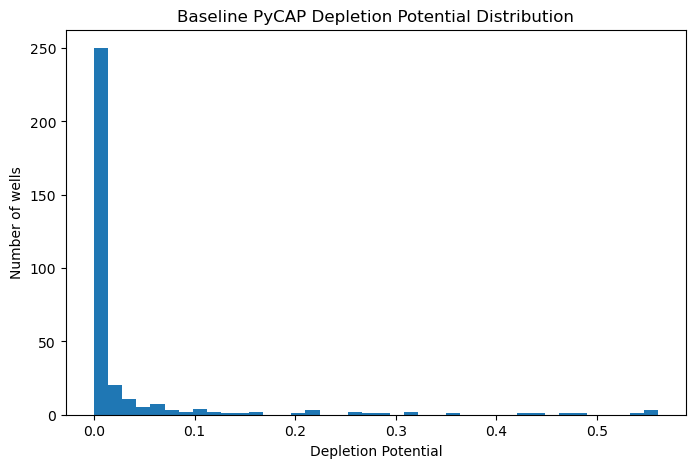

In [45]:
import matplotlib.pyplot as plt

dp_values = depletion_potential_df["Depletion_Potential"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(dp_values, bins=40)
plt.xlabel("Depletion Potential")
plt.ylabel("Number of wells")
plt.title("Baseline PyCAP Depletion Potential Distribution")
plt.show()


In [46]:
# Optional threshold summary
dp_thresholds = [0.001, 0.01, 0.05, 0.10, 0.20, 0.50]

threshold_summary = pd.DataFrame(
    [
        {
            "DP_threshold": threshold,
            "wells_at_or_above_threshold": int((depletion_potential_df["Depletion_Potential"] >= threshold).sum()),
        }
        for threshold in dp_thresholds
    ]
)

threshold_summary


,DP_threshold,wells_at_or_above_threshold
0,0.001,144
1,0.010,86
2,0.050,43
3,0.100,29
4,0.200,19
5,0.500,4


## 17. Optional: create a GeoDataFrame for future mapping

The original LPR PyCAP depletion-potential notebook mapped wells with GeoPandas.

For now, this cell only creates a GeoDataFrame if GeoPandas and Shapely are available. It saves a GeoJSON output to the run folder.


In [47]:
try:
    import geopandas as gpd
    from shapely.geometry import Point

    # The original LPR notebook used Point(-x, y), so we do the same here.
    geometry = [
        Point(-x, y) if pd.notna(x) and pd.notna(y) else None
        for x, y in zip(depletion_potential_df["x"], depletion_potential_df["y"])
    ]

    depletion_potential_gdf = gpd.GeoDataFrame(
        depletion_potential_df,
        geometry=geometry,
        crs="EPSG:4326",
    )

    dp_geojson_path = BASELINE_PYCAP_RUN_DIR / "depletion_potential_table.geojson"
    depletion_potential_gdf.to_file(dp_geojson_path, driver="GeoJSON")

    print(f"Saved depletion-potential GeoJSON to: {dp_geojson_path.relative_to(PROJECT_ROOT)}")
    display(depletion_potential_gdf.head())

except Exception as err:
    print("Could not create GeoDataFrame or GeoJSON output.")
    print(type(err).__name__)
    print(err)


Saved depletion-potential GeoJSON to: results/pycap_runs/baseline_pycap/depletion_potential_table.geojson


,well_id,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential,geometry
30,well_23627,23627,276.5,0.616045,89.484380,44.475732,0.345167,0.560296,POINT (-89.48438 44.47573)
222,well_68529,68529,219.9,0.489939,89.484333,44.479917,0.274004,0.559261,POINT (-89.48433 44.47992)
41,well_23653,23653,263.6,0.587303,89.498433,44.465117,0.326483,0.555901,POINT (-89.49843 44.46512)
1,well_466,466,315.9,0.703828,89.493950,44.461175,0.383091,0.544296,POINT (-89.49395 44.46117)
114,well_23934,23934,370.6,0.825700,89.477778,44.486112,0.398148,0.482195,POINT (-89.47778 44.48611)


## 18. Save a baseline PyCAP run summary table

The summary is saved to:

```text
results/pycap_runs/baseline_pycap_run_summary.csv
```


In [48]:
summary_rows = [
    {"item": "project_root", "value": str(PROJECT_ROOT)},
    {"item": "source_pycap_folder", "value": str(LPR_PYCAP_BASE_SOURCE_DIR.relative_to(PROJECT_ROOT))},
    {"item": "baseline_pycap_run_folder", "value": str(BASELINE_PYCAP_RUN_DIR.relative_to(PROJECT_ROOT))},
    {"item": "python_executable", "value": sys.executable},
    {"item": "pycap_yaml", "value": str(run_yaml_path.relative_to(PROJECT_ROOT))},
    {"item": "run_success_expected_outputs_exist", "value": bool(expected_output_check["exists"].all())},
    {"item": "elapsed_time", "value": str(elapsed)},
    {"item": "number_of_wells_in_yaml", "value": len(wells_df)},
    {"item": "number_of_wells_with_dp", "value": int(depletion_potential_df["Depletion_Potential"].notna().sum())},
    {"item": "dp_min", "value": float(dp_values.min()) if len(dp_values) else np.nan},
    {"item": "dp_max", "value": float(dp_values.max()) if len(dp_values) else np.nan},
    {"item": "dp_mean", "value": float(dp_values.mean()) if len(dp_values) else np.nan},
    {"item": "run_timestamp", "value": end_time.isoformat(timespec="seconds")},
]

baseline_summary = pd.DataFrame(summary_rows)
summary_path = PYCAP_RESULTS_DIR / "baseline_pycap_run_summary.csv"
baseline_summary.to_csv(summary_path, index=False)

print(f"Saved summary to: {summary_path.relative_to(PROJECT_ROOT)}")
baseline_summary


Saved summary to: results/pycap_runs/baseline_pycap_run_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,source_pycap_folder,data/raw/lpr_pycap/pycap_base
2,baseline_pycap_run_folder,results/pycap_runs/baseline_pycap
3,python_executable,/opt/conda/envs/gw_uncertainty/bin/python
4,pycap_yaml,results/pycap_runs/baseline_pycap/LPR_Redux.yml
5,run_success_expected_outputs_exist,True
6,elapsed_time,0:00:04.251355
7,number_of_wells_in_yaml,327
8,number_of_wells_with_dp,327
9,dp_min,0.0


## 19. Final interpretation

If this notebook ran successfully, then:

```text
data/raw/lpr_pycap/pycap_base/
```

is a valid clean copied baseline PyCAP source folder, and:

```text
results/pycap_runs/baseline_pycap/
```

is a valid runnable PyCAP workspace.

Recommended next steps:

1. Commit the executed notebook if you want GitHub to show the successful PyCAP baseline check.
2. Do **not** commit generated output files in `results/pycap_runs/baseline_pycap/` unless you intentionally want them version-controlled.
3. Start the next notebook:

```text
03_pycap_input_inventory.ipynb
```

That next notebook should focus on understanding every PyCAP input that could become uncertain, especially:

- transmissivity `T`
- storage `S`
- streambed conductance or related stream parameters
- pumping rate `Q`
- well-to-stream apportionment
- analytical solution choices
